# Capstone: your physics, end to end

A ball thrown with air drag that ramps on past a critical speed, built
from pieces the last three tutorials already taught, now put to work
together.

**Time:** ~10 min &middot; **Runs on:** CPU (GPU: a card picks it up
automatically) &middot; **You need:** [stop when you're done](../tutorials/03_stop_when_youre_done),
[a family of kernels](01_a_family_of_kernels),
[extend it by inheritance](02_extend_by_inheritance), [your own derivative](03_your_own_derivative)

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "_shared"))
from nb_helpers import DEVICE, batch_size, plot_style, torch_device, xp
plot_style()

In [2]:
import math

import numpy as np
import torch

print("DEVICE:", DEVICE, "| torch:", torch_device)

DEVICE: cpu | torch: cpu


## Two kernel shapes for the same physics

`Perturbed` below is a FRESH `Kind` hierarchy built for this page, not a
reuse of [a family of kernels](01_a_family_of_kernels)'s `Orbit`: that
one declared `r`/`v` as plain inputs, but `flight_sim` here needs them
`Mutable` (it writes the next state back into them for `eagle.simulate`
to carry forward), while `flight_step` needs them as plain inputs (old
state in) with separate `r_next`/`v_next` outputs. Same idea — one
`Kind`, more than one model — a different concrete vocabulary for a
different job, plus `terminated`, which neither earlier model needed.

In [3]:
import hawk
from hawk import Mutable, Param, Scalar, Terminated, Vector
from hawk.ext import KernelKind, primitive
from hawk.math import exp, log, norm, vec


class Orbit(KernelKind, slug="orbit_capstone"):
    terminated: Terminated
    dt: Param
    g: Param


class Perturbed(Orbit, slug="perturbed_capstone"):
    cd: Scalar

`speed_ramp` is [the same custom primitive](03_your_own_derivative) as
last tutorial, declared fresh for this page's own kernels:

In [4]:
@primitive("capstone_speed_ramp",
           vjp=lambda s, bar: bar / (1.0 + exp(-s)),
           jvp=lambda s, ds: ds / (1.0 + exp(-s)))
def speed_ramp(s):
    return log(1.0 + exp(s))

`flight_sim` reads its own state before writing it — the value carried
from the previous launch, exactly what `eagle.simulate`'s repeated
launches need:

In [5]:
@Perturbed
def flight_sim(terminated, dt, g, cd, v_crit: Param,
               r: Mutable[Vector[3]], v: Mutable[Vector[3]]):
    ramp = speed_ramp(norm(v) - v_crit)
    a = vec(0.0, 0.0, -g) - cd * ramp * v
    v = v + dt * a
    r = r + dt * v   # sequential: uses the NEW v (tutorial 03's note)
    terminated = r[2] < 0.0

`flight_step` is the SAME physics, as a pure function instead: old `r`,
`v` in; new `r`, `v` out — the shape a derivative, or `loss.backward()`,
can see the whole of:

In [6]:
@Perturbed
def flight_step(r: Vector[3], v: Vector[3], v_crit: Param, dt, g, cd, terminated,
                 r_next: Mutable[Vector[3]], v_next: Mutable[Vector[3]]):
    ramp = speed_ramp(norm(v) - v_crit)
    a = vec(0.0, 0.0, -g) - cd * ramp * v
    v_next = v + dt * a
    r_next = r + dt * v_next   # sequential: uses NEW v_next (tutorial 03's note)

## Run it at scale

`eagle.simulate` already knows how to step a kernel until every sample's
`terminated` flag is set — [stop when you're done](../tutorials/03_stop_when_youre_done)
covered this; here it runs `flight_sim` over a real batch:

In [7]:
n = batch_size(gpu=1_000_000, cpu=100_000)
rng = np.random.default_rng(0)
speed = 20.0 + 20.0 * rng.uniform(size=n)
elevation = np.radians(20.0) + np.radians(50.0) * rng.uniform(size=n)
heading = 2.0 * np.pi * rng.uniform(size=n)
v0 = np.stack([speed * np.cos(elevation) * np.cos(heading),
               speed * np.cos(elevation) * np.sin(heading),
               speed * np.sin(elevation)])
r0 = np.zeros((3, n)); r0[2] = 1.0
cd0 = np.full(n, 0.004)


`eagle.simulate` takes the kernel and every plane it reads or writes, by name:


In [8]:
import eagle

result = eagle.simulate(
    flight_sim, r=xp.asarray(r0), v=xp.asarray(v0),
    dt=0.02, g=9.81, cd=xp.asarray(cd0), v_crit=25.0, max_steps=2000)
print(f"{n:,} balls, {result.status}, {result.steps} steps, "
      f"{int(result.finished.sum()):,} landed, {result.wall_s:.3f} s wall")


100,000 balls, finished, 384 steps, 100,000 landed, 0.115 s wall


## A derivative needs the pure shape

`flight_sim` reads `v` and `r` before writing them — the value carried
from the previous launch — and `hawk.diff` refuses to differentiate
through that on principle: it keeps no tape between launches, so a
derivative through a recurrence it cannot see the whole of would be a
plausible wrong answer, not a crash. `flight_step` is the per-launch term
the refusal message points to:

In [9]:
from hawk.diff import vjp
from hawk.ir import HawkError

try:
    vjp(flight_sim, wrt=("v",))
except HawkError as exc:
    print("refused:", str(exc)[:120])

refused: 'r' is read before it is assigned: a plane's launch-start value is a recurrence across launches; its derivative needs th


## Wrapping the pure kernel for PyTorch

`eagle.frameworks.torch.function` wraps `flight_step` as a
`torch.autograd.Function`: its backward runs hawk's derived reverse-mode
kernel, its forward-mode AD the derived forward-mode one.

In [10]:
from eagle.frameworks import torch as eagle_torch

step = eagle_torch.function(flight_step, wrt=("r", "v", "cd"))

nn = 32
gen = torch.Generator().manual_seed(0)
r = torch.randn(3, nn, dtype=torch.float64, generator=gen, device=torch_device,
                requires_grad=True)
v = torch.randn(3, nn, dtype=torch.float64, generator=gen, device=torch_device,
                requires_grad=True) + 5.0
cd = torch.full((nn,), 0.01, dtype=torch.float64, device=torch_device,
                 requires_grad=True)
not_landed = torch.zeros(nn, dtype=torch.bool, device=torch_device)


def call(r, v, cd):
    return step(r=r, v=v, v_crit=25.0, dt=0.02, g=9.81, cd=cd, terminated=not_landed)

`torch.autograd.gradcheck` is PyTorch's own standard check: it perturbs
each input by a tiny amount, compares the result to `call`'s reported
gradient, and raises if they disagree beyond its tolerance — the same
idea as this family's own finite-difference checks, run by a library
instead of by hand:

In [11]:
ok = torch.autograd.gradcheck(call, (r, v, cd),
                               check_forward_ad=True, check_batched_grad=False)
print("gradcheck (reverse AND forward mode):", ok)

gradcheck (reverse AND forward mode): True


One more check, kept for the dashboard at the end of this page: `cd`'s
own gradient against a hand-rolled central difference.

In [12]:
r_next, v_next = call(r, v, cd)
((r_next ** 2).sum() + (v_next ** 2).sum()).backward()
ad_grad = cd.grad.clone()

H = 1e-6
with torch.no_grad():
    rp, vp = call(r, v, cd + H)
    rm, vm = call(r, v, cd - H)
    fd_grad = (((rp ** 2).sum(dim=0) + (vp ** 2).sum(dim=0))
               - ((rm ** 2).sum(dim=0) + (vm ** 2).sum(dim=0))) / (2 * H)
print("max |AD - FD| over", nn, "samples:", float((ad_grad - fd_grad).abs().max()))

max |AD - FD| over 32 samples: 1.4806493336916615e-08


## Synthetic throws to fit against

256 balls thrown with a TRUE drag coefficient of 0.004/m, 5 cm of
measurement noise added — the data the rest of this page fits `cd`
against:

In [13]:
DT, G, VCRIT, STEPS = 0.02, 9.81, 25.0, 60
N, CD_TRUE = 256, 0.004

rng2 = torch.Generator().manual_seed(1)
speed_t = 20.0 + 20.0 * torch.rand(N, dtype=torch.float64, generator=rng2)
elevation_t = (math.radians(20.0) + math.radians(50.0)
               * torch.rand(N, dtype=torch.float64, generator=rng2))
heading_t = 2.0 * math.pi * torch.rand(N, dtype=torch.float64, generator=rng2)
v0_t = torch.stack([speed_t * elevation_t.cos() * heading_t.cos(),
                     speed_t * elevation_t.cos() * heading_t.sin(),
                     speed_t * elevation_t.sin()]).to(torch_device)
r0_t = torch.zeros(3, N, dtype=torch.float64, device=torch_device)
r0_t[2] = 1.0

In [14]:
def thrown_to(cd_value):
    """Roll every ball out to landing at a fixed cd; no grad needed here."""
    cd = cd_value.expand(N).contiguous()
    r, v = r0_t, v0_t
    with torch.no_grad():
        for _ in range(STEPS):
            landed = r[2] < 0.0
            r_next, v_next = step(r=r, v=v, v_crit=VCRIT, dt=DT, g=G, cd=cd,
                                   terminated=landed)
            r, v = torch.where(landed, r, r_next), torch.where(landed, v, v_next)
    return r


Roll out the truth, add sensor noise, and start the fit from a value 4x too high:


In [15]:
truth_final = thrown_to(torch.tensor(CD_TRUE, dtype=torch.float64, device=torch_device))
noise_gen = torch.Generator().manual_seed(2)
observed = truth_final + 0.05 * torch.randn(truth_final.shape, dtype=torch.float64,
                                             generator=noise_gen).to(torch_device)
CD_GUESS = 4.0 * CD_TRUE   # clearly wrong on purpose -- the fit has real work to do
print("true cd:", CD_TRUE, "| starting guess:", CD_GUESS)


true cd: 0.004 | starting guess: 0.016


## Fit cd with SGD

`cd`, registered as a `torch.nn.Parameter` and run through `flight_step`
each step, is an ordinary model: `loss.backward()` computes its
gradient, and `torch.optim.SGD` (plain stochastic gradient descent: each
step moves the parameter by `-learning_rate * gradient`, nothing
fancier) updates it.

In [16]:
class BallisticRaw(torch.nn.Module):
    def __init__(self, cd_guess):
        super().__init__()
        self.cd = torch.nn.Parameter(torch.tensor(cd_guess, dtype=torch.float64))

    def forward(self):
        cd = self.cd.expand(N).contiguous()
        r, v = r0_t, v0_t
        for _ in range(STEPS):
            landed = r[2] < 0.0
            r_next, v_next = step(r=r, v=v, v_crit=VCRIT, dt=DT, g=G, cd=cd,
                                  terminated=landed)
            r, v = torch.where(landed, r, r_next), torch.where(landed, v, v_next)
        return r

One step is already a problem:

In [17]:
raw_model = BallisticRaw(CD_GUESS).to(torch_device)
raw_opt = torch.optim.SGD(raw_model.parameters(), lr=1e-3)
raw_opt.zero_grad()
loss = ((raw_model() - observed) ** 2).mean()
loss.backward()
grad_before = raw_model.cd.grad.item()
raw_opt.step()
print(f"loss = {loss.item():.5f}, d(loss)/d(cd) = {grad_before:.2f}")
msg = f"cd: {CD_GUESS} -> {raw_model.cd.item():.5f} after ONE step"
print(msg, "-- already negative, unphysical")

loss = 0.55714, d(loss)/d(cd) = 77.12
cd: 0.016 -> -0.06112 after ONE step -- already negative, unphysical


## The log-reparameterization trick

`cd`'s gradient (printed above, around 77) is large relative to `cd`'s
own tiny scale (0.004-0.016), so an ordinary step overshoots straight
past zero. Optimizing `log(cd)` instead keeps the step proportional to
the parameter's own size, and `.exp()` in `forward` keeps `cd` positive
no matter what:

In [18]:
class Ballistic(torch.nn.Module):
    def __init__(self, cd_guess):
        super().__init__()
        self.log_cd = torch.nn.Parameter(
            torch.tensor(math.log(cd_guess), dtype=torch.float64))

    def forward(self, track_path=False):
        cd = self.log_cd.exp().expand(N).contiguous()
        r, v, path = r0_t, v0_t, [r0_t]
        for _ in range(STEPS):
            landed = r[2] < 0.0
            r_next, v_next = step(r=r, v=v, v_crit=VCRIT, dt=DT, g=G, cd=cd,
                                  terminated=landed)
            r, v = torch.where(landed, r, r_next), torch.where(landed, v, v_next)
            if track_path:
                path.append(r)
        return torch.stack(path) if track_path else r

In [19]:
model = Ballistic(CD_GUESS).to(torch_device)
log_opt = torch.optim.SGD(model.parameters(), lr=1e-3)
for epoch in range(5):
    log_opt.zero_grad()
    loss = ((model() - observed) ** 2).mean()
    loss.backward()
    log_opt.step()
    msg = f"epoch {epoch}: loss = {loss.item():.5f}"
    print(msg, f"cd = {model.log_cd.exp().item():.5f}")

epoch 0: loss = 0.55714 cd = 0.01598
epoch 1: loss = 0.55562 cd = 0.01596
epoch 2: loss = 0.55411 cd = 0.01594
epoch 3: loss = 0.55260 cd = 0.01592


epoch 4: loss = 0.55110 cd = 0.01590


Same learning rate that broke `cd` directly now makes small, stable
progress — real, but slow enough that a sharper optimizer is worth
reaching for.

## Switch to L-BFGS

L-BFGS (limited-memory BFGS: a quasi-Newton optimizer that uses
curvature, not just the gradient, to take much bigger steps than SGD)
may re-evaluate the loss several times per step, so PyTorch asks for a
**closure** — a zero-argument function it can call again itself, as many
times as its line search needs — instead of one `loss.backward()`. Same
`Ballistic` model, starting fresh from the same guess:

In [20]:
model = Ballistic(CD_GUESS).to(torch_device)
optimizer = torch.optim.LBFGS(model.parameters(), max_iter=20,
                               line_search_fn="strong_wolfe")
loss_hist, cd_hist = [], []


def closure():
    optimizer.zero_grad()
    loss = ((model() - observed) ** 2).mean()
    loss.backward()
    loss_hist.append(loss.item())
    cd_hist.append(model.log_cd.exp().item())
    return loss

In [21]:
for epoch in range(4):
    optimizer.step(closure)

fitted_cd = model.log_cd.exp().item()
print(f"cd: {CD_GUESS:.5f} (start) -> {fitted_cd:.5f} (fitted), {CD_TRUE:.5f} (true)")
print(f"loss: {loss_hist[0]:.5f} (start) -> {loss_hist[-1]:.5f} (final) m^2, "
      f"over {len(loss_hist)} line-search evaluations")

with torch.no_grad():
    truth_path = Ballistic(CD_TRUE).to(torch_device)(track_path=True)

cd: 0.01600 (start) -> 0.00400 (fitted), 0.00400 (true)
loss: 0.55714 (start) -> 0.00247 (final) m^2, over 11 line-search evaluations


## The payoff, four ways

Thrown trajectories at the true `cd`, the AD-vs-finite-difference check
from earlier, the loss curve, and the fitted `cd` converging to the true
value:

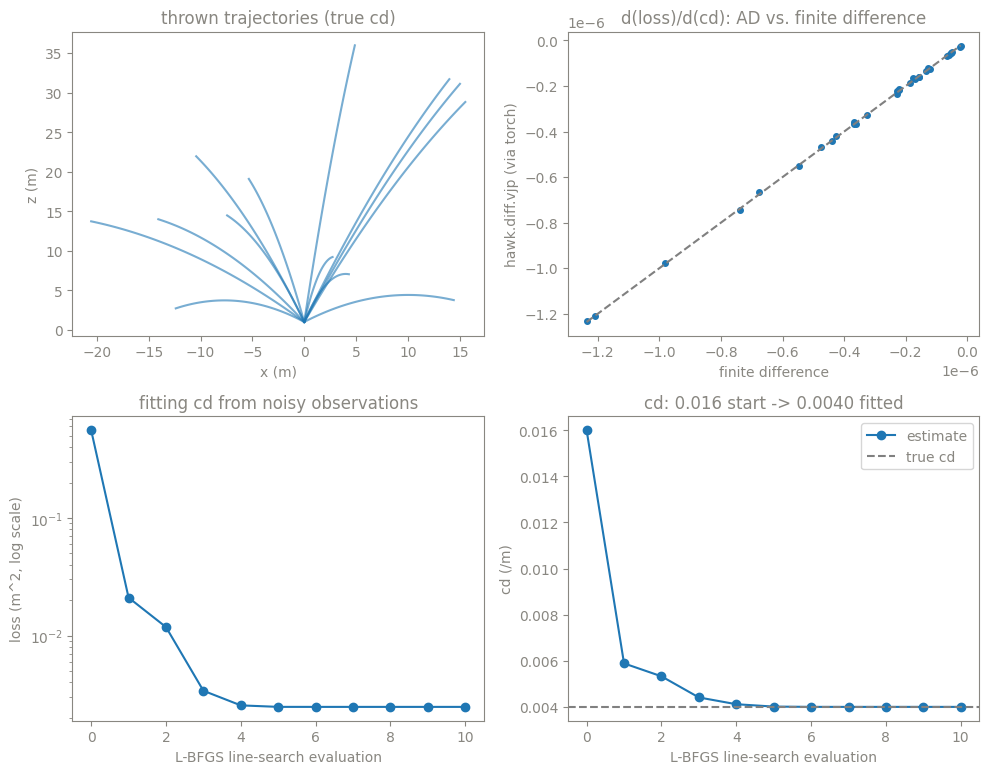

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

path_np = truth_path.detach().cpu().numpy()
for i in range(0, N, max(1, N // 12)):
    axes[0, 0].plot(path_np[:, 0, i], path_np[:, 2, i], color="tab:blue", alpha=0.6)
axes[0, 0].set_xlabel("x (m)"); axes[0, 0].set_ylabel("z (m)")
axes[0, 0].set_title("thrown trajectories (true cd)")

ad_np, fd_np = ad_grad.cpu().numpy(), fd_grad.cpu().numpy()
axes[0, 1].plot(fd_np, ad_np, "o", ms=4)
lims = [min(fd_np.min(), ad_np.min()), max(fd_np.max(), ad_np.max())]
axes[0, 1].plot(lims, lims, "--", color="gray")
axes[0, 1].set_xlabel("finite difference"); axes[0, 1].set_ylabel("hawk.diff.vjp (via torch)")
axes[0, 1].set_title("d(loss)/d(cd): AD vs. finite difference")

axes[1, 0].plot(loss_hist, "o-")
axes[1, 0].set_yscale("log")
axes[1, 0].set_xlabel("L-BFGS line-search evaluation"); axes[1, 0].set_ylabel("loss (m^2, log scale)")
axes[1, 0].set_title("fitting cd from noisy observations")

axes[1, 1].plot(cd_hist, "o-", label="estimate")
axes[1, 1].axhline(CD_TRUE, color="gray", linestyle="--", label="true cd")
axes[1, 1].set_xlabel("L-BFGS line-search evaluation"); axes[1, 1].set_ylabel("cd (/m)")
axes[1, 1].set_title(f"cd: {CD_GUESS:.3f} start -> {fitted_cd:.4f} fitted")
axes[1, 1].legend()

fig.tight_layout()
plt.show()

## What just happened

- One `Kind` hierarchy and one custom primitive fed TWO kernels:
  `flight_sim` (reads its own state before writing it, for `eagle.simulate`'s
  repeated launches) and `flight_step` (a pure per-launch function, for
  derivatives and PyTorch) — the same physics, two shapes for two jobs.
- `hawk.diff` refuses to differentiate a kernel that carries state across
  launches; `eagle.frameworks.torch.function` differentiates the pure
  `flight_step` instead, and its reverse- and forward-mode gradients land
  on the finite difference (`gradcheck` and a hand-rolled check both agree).
- `cd`'s gradient is too large for its own tiny scale, so plain SGD on
  `cd` overshoots past zero in one step; optimizing `log(cd)` with L-BFGS
  instead recovers the true drag coefficient from noisy, simulated throws.

## Try this

Change `v_crit` and watch the learned `cd` drift if the model's ramp no
longer matches the data's — the fit is only as good as the physics it is
given.

## Next

[eagle's tutorials](https://amasat01.github.io/eagle/) pick this up from the
runtime side: graphs, compaction, and training at scale. Short a primitive,
or need to splice raw C++ instead? See
[when hawk can't spell it](when_hawk_cant_spell_it).